In [1]:
import iree.compiler
import iree.runtime
import numpy as np
from timeit import timeit

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def get_dataframe(compute, store, load, size):
    return pd.DataFrame({
        "weight": compute / (store + load),
        "size": size
    }, index=[0])

# def timeit(stmt, n=100):
#     return ti(stmt, globals=globals(), number=n) * 1000 / n

dims = [16 * (x + 1) for x in range(64)]
N = int(1e3)

## Unary Ops

In [2]:
mlir = """
!type = tensor<{N}xf32>

ml_program.global private mutable @cache : !type

func.func @compute(%x : !type) -> !type {
  %res = {OP} %x : !type
  return %res : !type
}

func.func @store(%val : !type) {
  ml_program.global_store @cache = %val : !type
  return
}

func.func @load() -> !type {
  %res = ml_program.global_load @cache : !type
  return %res : !type
}
"""

ops = ["math.exp", "math.rsqrt", "math.tanh"]

unary_df = pd.DataFrame()
for op in ops:
    for dim in dims:
        module = compile_str(
            mlir.replace("{N}", f"{dim}").replace("{OP}", op)
        )
        lhs = np.random.randn(dim).astype(np.float32)
        res = module.compute(lhs).to_host()
        compute = timeit("module.compute(lhs)", globals=locals(), number=N) / N
        store = timeit("module.store(res)", globals=locals(), number=N) / N
        load = timeit("module.load()", globals=locals(), number=N) / N
        df = get_dataframe(compute, store, load, dim)
        df["operation"] = op[op.index(".")+1:]
        unary_df = pd.concat([unary_df, df])

## Binary Ops

In [3]:
mlir = """
!type = tensor<{N}xf32>

ml_program.global private mutable @cache : !type

func.func @compute(%l : !type, %r : !type) -> !type {
  %res = {OP} %l, %r : !type
  return %res : !type
}

func.func @store(%val : !type) {
  ml_program.global_store @cache = %val : !type
  return
}

func.func @load() -> !type {
  %res = ml_program.global_load @cache : !type
  return %res : !type
}
"""

ops = ["arith.addf", "arith.subf", "arith.mulf", "arith.divf", "math.powf"]

binary_df = pd.DataFrame()
for op in ops:
    for dim in dims:
        module = compile_str(
            mlir.replace("{N}", f"{dim}").replace("{OP}", op)
        )
        lhs = np.random.randn(dim).astype(np.float32)
        rhs = np.random.randn(dim).astype(np.float32)
        res = module.compute(lhs, rhs).to_host()
        compute = timeit("module.compute(lhs, rhs)", globals=locals(), number=N) / N
        store = timeit("module.store(res)", globals=locals(), number=N) / N
        load = timeit("module.load()", globals=locals(), number=N) / N
        df = get_dataframe(compute, store, load, dim)
        df["operation"] = op[op.index(".")+1:]
        binary_df = pd.concat([binary_df, df])

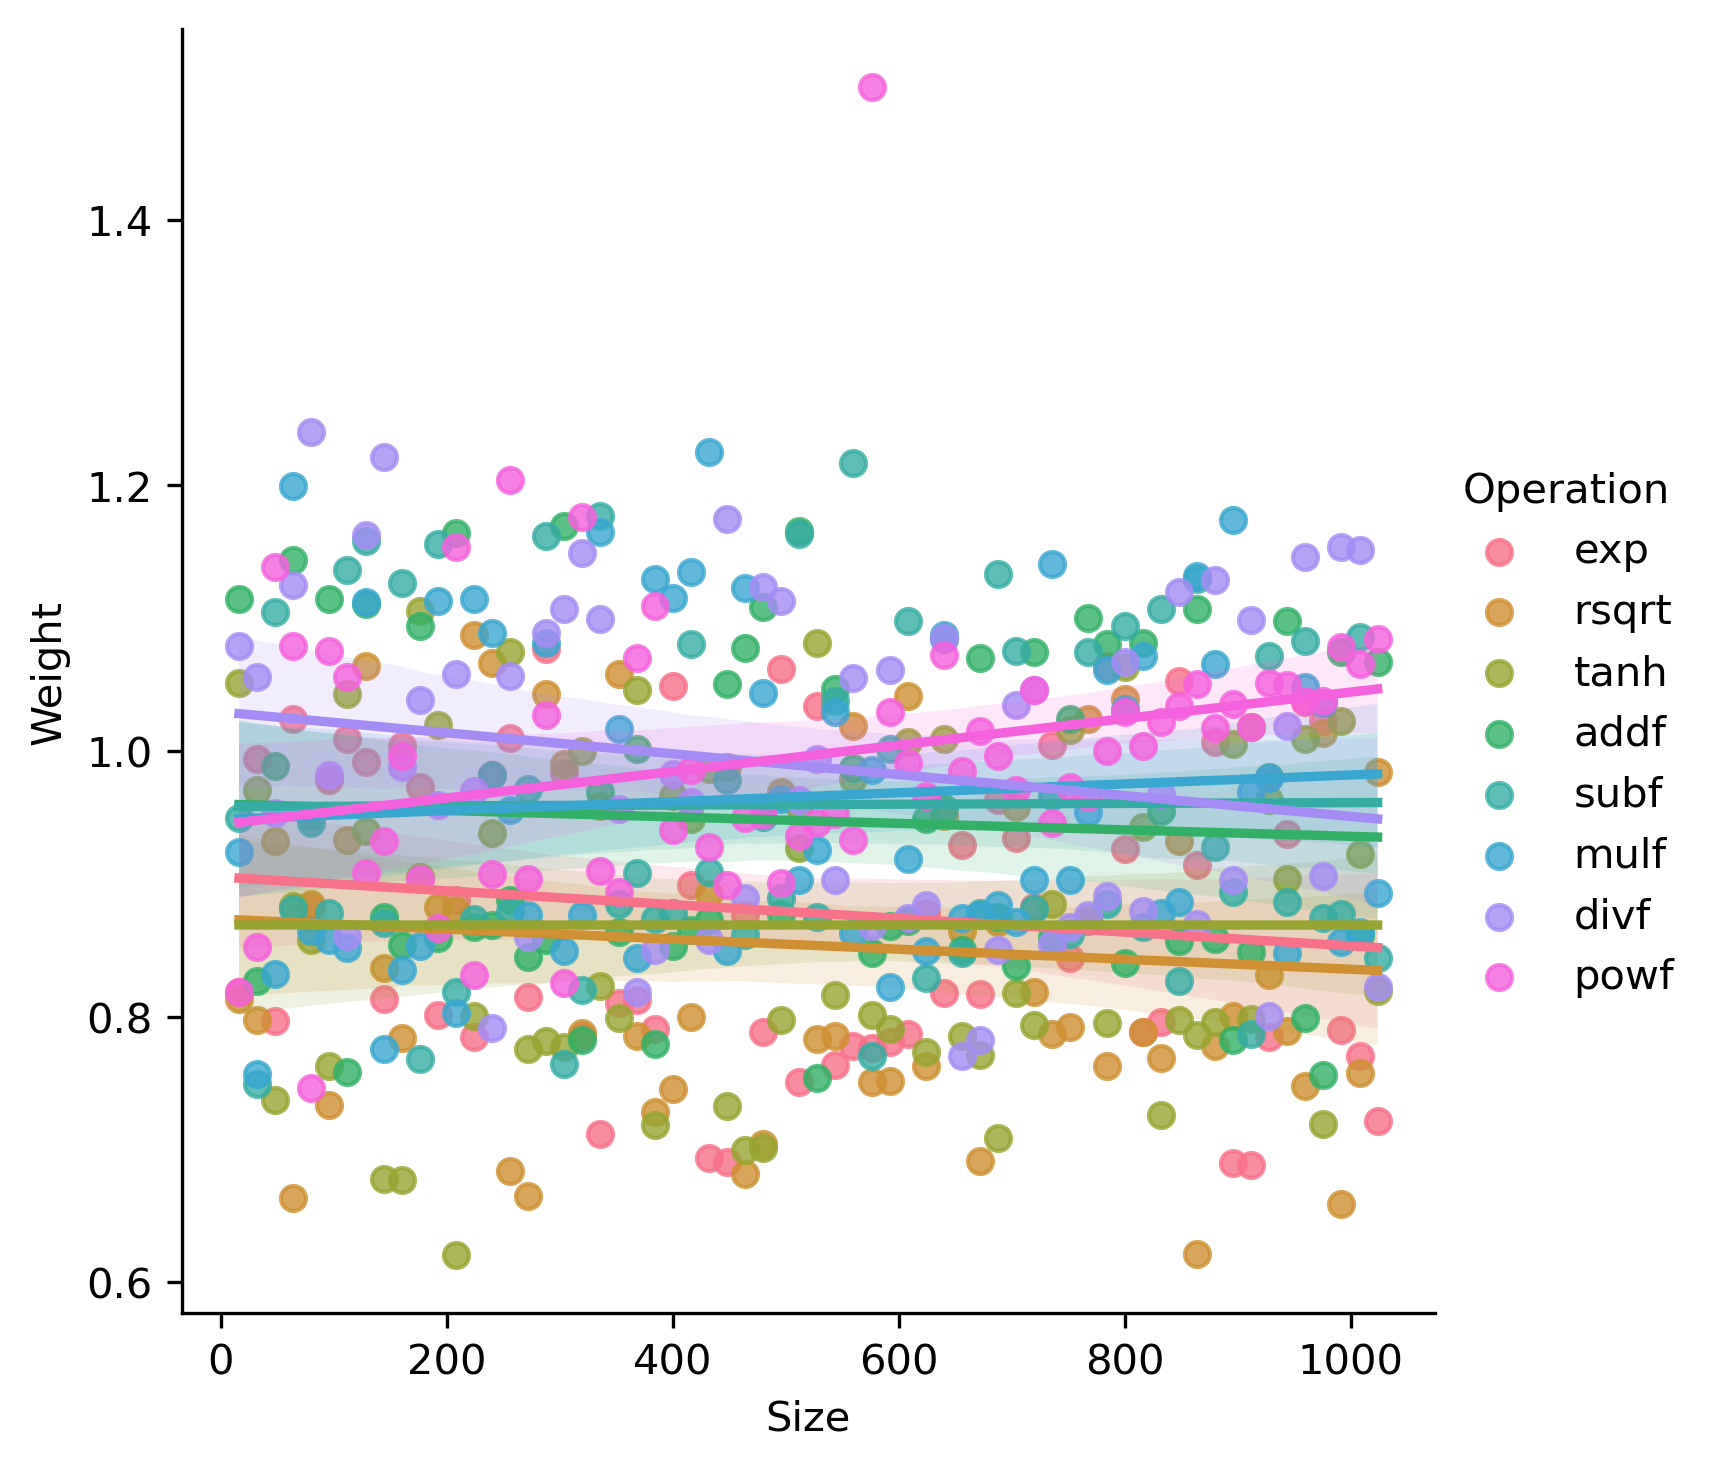

In [4]:
df = pd.concat([unary_df, binary_df])
lm = sns.lmplot(df, x="size", y="weight", hue="operation")

plt.ylabel("Weight")
plt.xlabel("Size")
lm.legend.set_title("Operation")

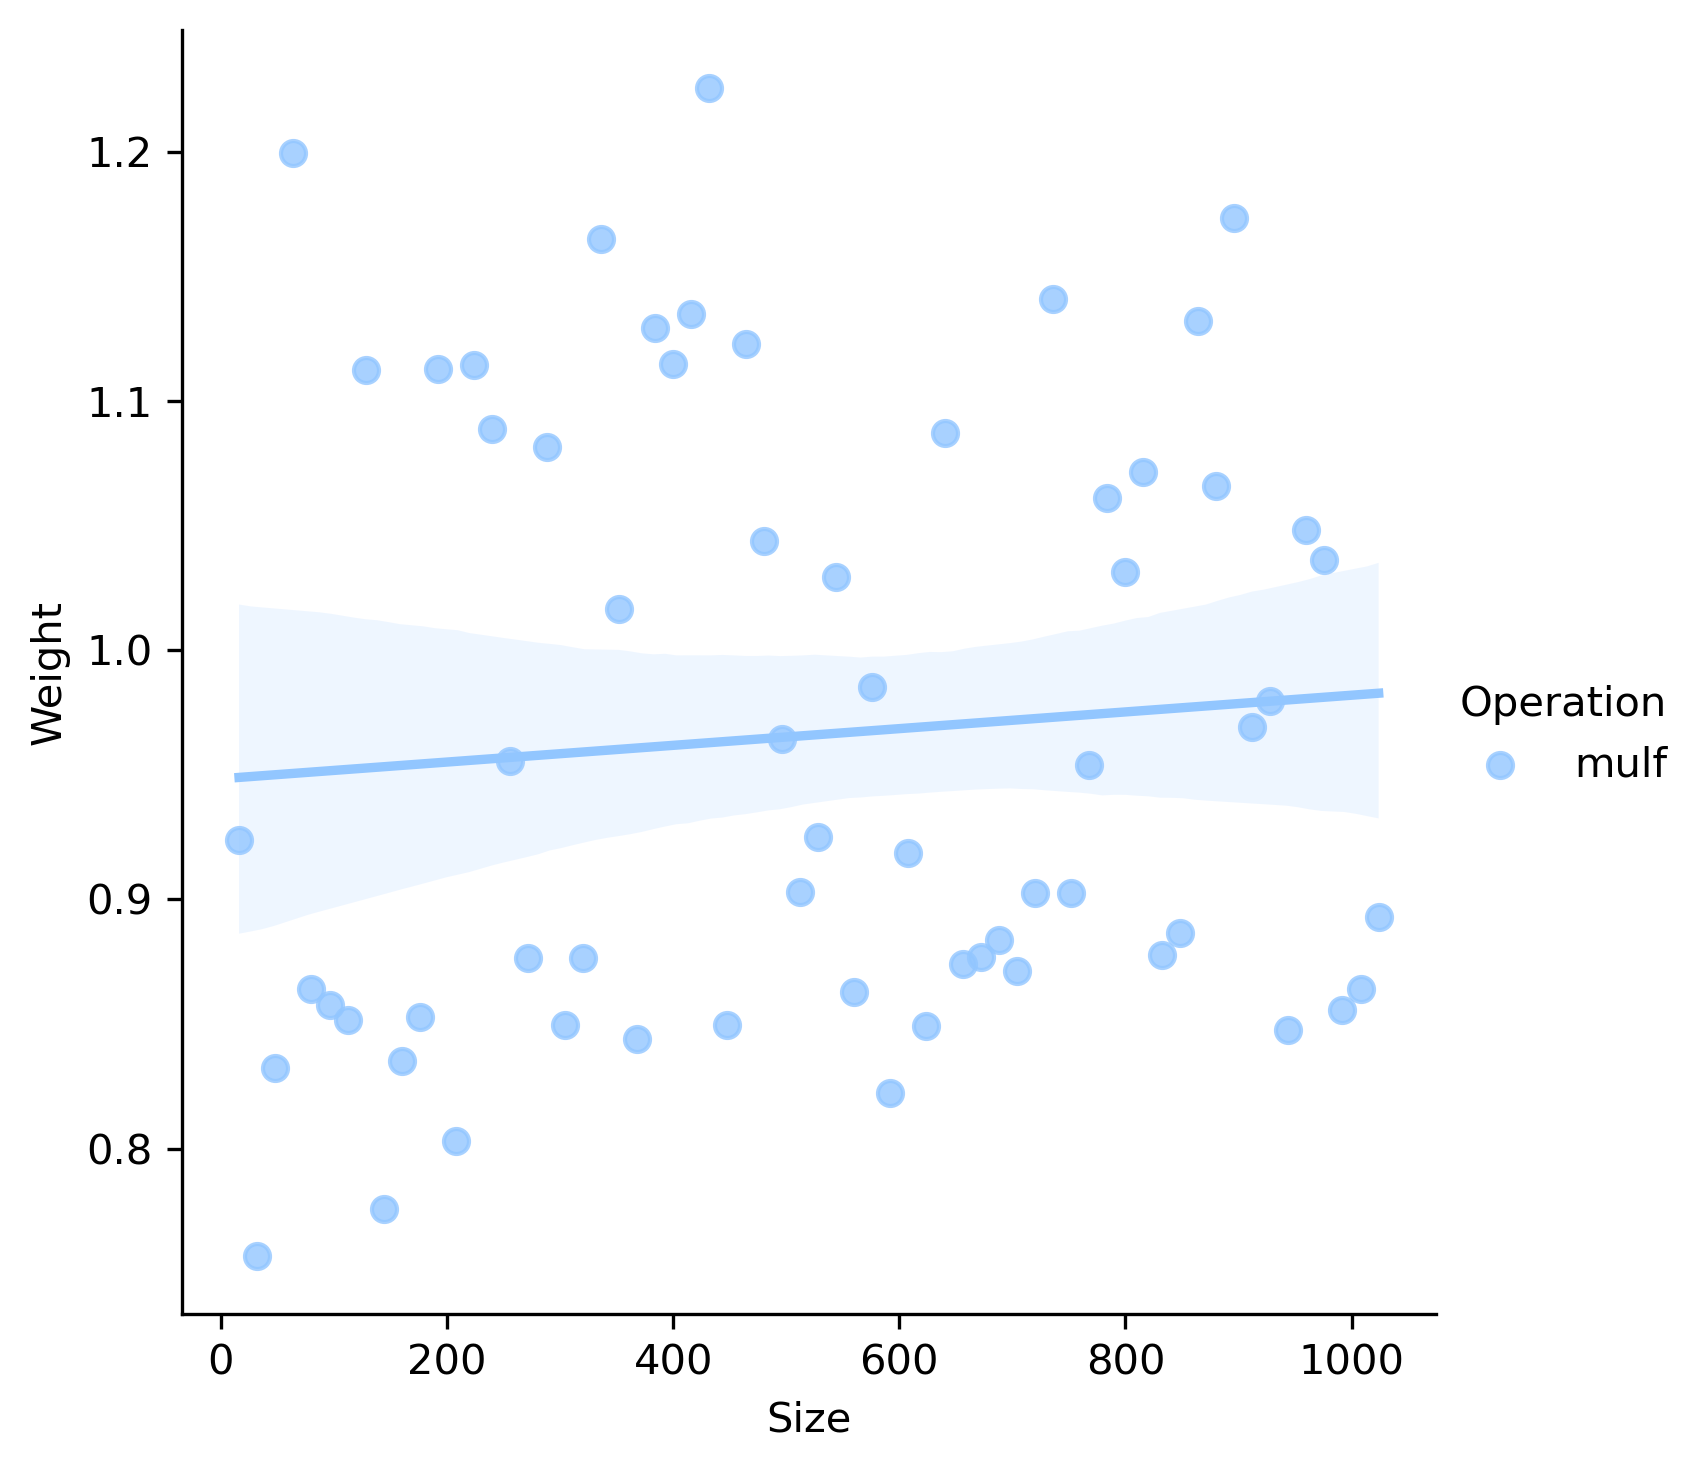

In [5]:
df = pd.concat([unary_df, binary_df])
lm = sns.lmplot(df[df.operation == "mulf"], x="size", y="weight", hue="operation")

plt.ylabel("Weight")
plt.xlabel("Size")
lm.legend.set_title("Operation")